In [1]:
import pandas as pd
import os
from sqlalchemy import create_engine
username = "postgres"
password = "history123"
host = "localhost"
port = "5432"
database = "supply_chain_db"
connection_string = f'postgresql://{username}:{password}@{host}:{port}/{database}'
engine = create_engine(connection_string)
with engine.connect() as con:
    print("connected!!")

connected!!


In [2]:
df = pd.read_csv("supply_chain_cleaned.csv")

C:\Users\RUCHIR\AppData\Local\Temp\ipykernel_19652\3548461558.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("supply_chain_cleaned.csv")


In [3]:
df.to_sql("supply_chain", con = engine, if_exists="replace", index=False)
print("data uploaded")

data uploaded


In [4]:
df_sql = pd.read_sql("SELECT * FROM supply_chain LIMIT 5;", engine)
df_sql.head()

,payement_type,days_for_shipping_(real),days_for_shipment_(scheduled),benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_status,product_card_id,product_category_id,product_description,product_image,product_name,product_price,product_status,shipping_date_(dateorders),shipping_mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,1360,73,Not available,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,1360,73,Not available,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,1360,73,Not available,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,COMPLETE,1360,73,Not available,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,PENDING_PAYMENT,1360,73,Not available,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


In [5]:
df.columns.tolist()

['payement_type',
 'days_for_shipping_(real)',
 'days_for_shipment_(scheduled)',
 'benefit_per_order',
 'sales_per_customer',
 'delivery_status',
 'late_delivery_risk',
 'category_id',
 'category_name',
 'customer_city',
 'customer_country',
 'customer_email',
 'customer_fname',
 'customer_id',
 'customer_lname',
 'customer_password',
 'customer_segment',
 'customer_state',
 'customer_street',
 'customer_zipcode',
 'department_id',
 'department_name',
 'latitude',
 'longitude',
 'market',
 'order_city',
 'order_country',
 'order_customer_id',
 'order_date_(dateorders)',
 'order_id',
 'order_item_cardprod_id',
 'order_item_discount',
 'order_item_discount_rate',
 'order_item_id',
 'order_item_product_price',
 'order_item_profit_ratio',
 'order_item_quantity',
 'sales',
 'order_item_total',
 'order_profit_per_order',
 'order_region',
 'order_state',
 'order_status',
 'product_card_id',
 'product_category_id',
 'product_description',
 'product_image',
 'product_name',
 'product_price',
 '

In [6]:
date_colums = ["order_date_(dateorders)", "shipping_date_(dateorders)"]
df[date_colums] = df[date_colums].apply(pd.to_datetime)

## EDA analysis
### Q1 which product categories contribute the most to total sales (Top 10)
  
- Why are we solving it?

To identify the company's biggest revenue-generating categories.

- Business Problem it solves
- Helps management focus on high-performing categories.
- Guides inventory planning.
- Helps marketing decide where to invest.
- Identifies weak categories that may need improvement.

In [7]:
category_sales = ( round(df.groupby("category_name")["sales"].sum().sort_values(ascending=False).head(10).reset_index(), 2))
def format_currency(x):
    if x >= 1_000_000:
        return f"${x/1_000_000:.2f}M"
    elif x>= 1_000:
        return f"${x/1_000:.2f}K"
    else:
        return f"${x:.2f}"
category_sales_table = category_sales.copy()
category_sales_table["sales"] = category_sales_table["sales"].apply(format_currency)
category_sales_table

,category_name,sales
0,Fishing,$6.93M
1,Cleats,$4.43M
2,Camping & Hiking,$4.12M
3,Cardio Equipment,$3.69M
4,Women's Apparel,$3.15M
5,Water Sports,$3.11M
6,Men's Footwear,$2.89M
7,Indoor/Outdoor Games,$2.89M
8,Shop By Sport,$1.31M
9,Computers,$663.00K


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm

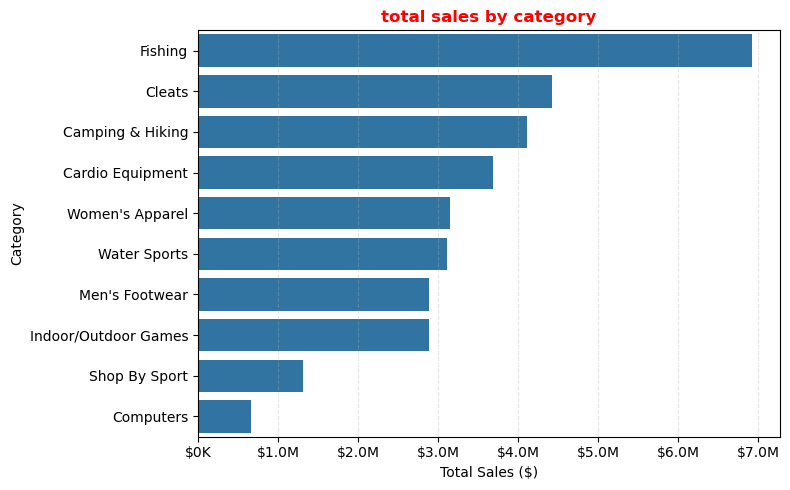

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(
    data = category_sales,
    x= "sales",
    y= "category_name"
)
plt.title("total sales by category", fontsize = 12, color = "red", weight = "bold")
plt.xlabel("Total Sales ($)")
plt.ylabel("Category")

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(
         lambda x, pos: f'${x/1_000_000:.1f}M' if x >= 1_000_000 else f'${x/1000:.0f}K'
    )
)
plt.grid(axis = 'x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Q2 Country Wise sales Distribution

In [10]:
country_wise_sales = df.groupby("order_country").agg(
    total_sales = ("sales", "sum"),
    avg_profit = ("benefit_per_order", "mean"),
    total_orders = ("order_id", "count")
).sort_values( by = "total_sales", ascending=False).reset_index()
country_wise_sales["total_sales"] = country_wise_sales["total_sales"].apply(format_currency)
country_wise_sales["avg_profit"] = country_wise_sales["avg_profit"].apply(format_currency)
country_wise_sales.head(10)

,order_country,total_sales,avg_profit,total_orders
0,Estados Unidos,$4.88M,$21.76,24840
1,Francia,$2.88M,$24.79,13222
2,México,$2.63M,$23.02,13172
3,Alemania,$2.07M,$20.37,9564
4,Australia,$1.69M,$20.01,8497
5,Reino Unido,$1.61M,$24.78,7302
6,Brasil,$1.59M,$23.38,7987
7,China,$1.17M,$21.22,5758
8,Italia,$1.07M,$24.36,4989
9,India,$962.40K,$20.85,4783


### PLOT

C:\Users\RUCHIR\AppData\Local\Temp\ipykernel_19652\589839435.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


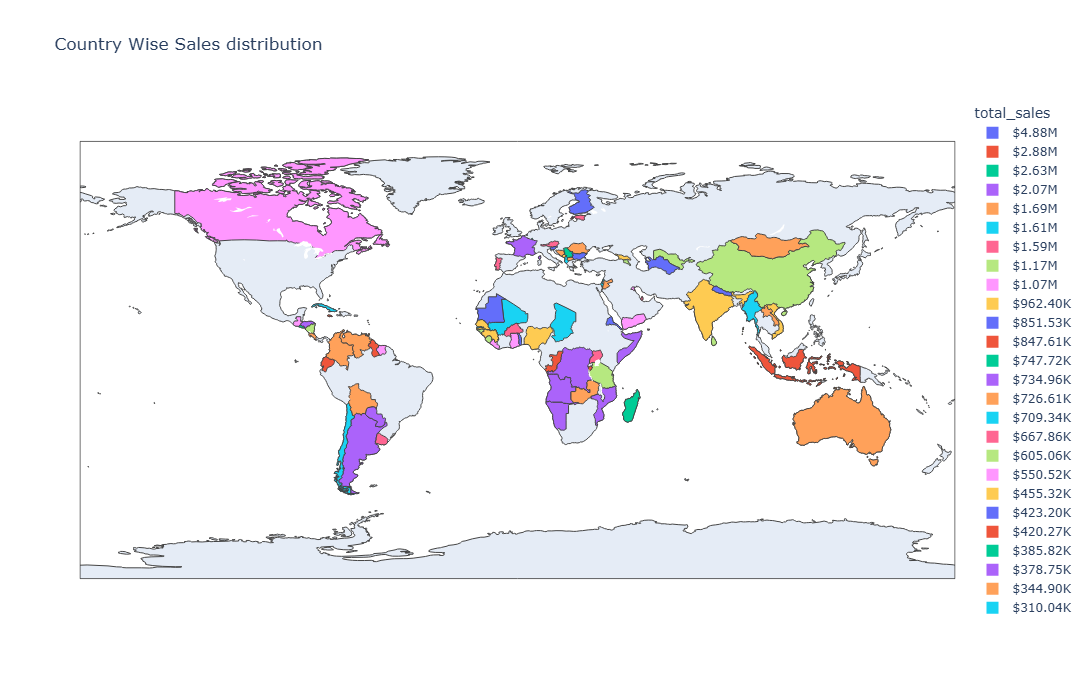

In [11]:
import plotly.express as px
fig = px.choropleth(
    country_wise_sales,
    locations="order_country",
    locationmode="country names",
    color="total_sales",
    hover_name = "order_country",
    hover_data={
        "total_sales",
        "avg_profit",
        "total_orders"
    },
    color_continuous_scale="Blues",
    title= "Country Wise Sales distribution",
    width=1000,
    height = 700
)
fig.show()


## Q3 "Which countries generate the highest sales and profits while maintaining the fastest delivery performance?"

In [12]:
country_wise_shipping = df.groupby("order_country").agg(
    total_sales = ("sales", "sum"),
    total_profit = ("order_profit_per_order", "sum"),
    avg_real_shipping_days = ("days_for_shipping_(real)", "mean"),
    avg_scheduled_shipping_days = ("days_for_shipment_(scheduled)", "mean"),
    avg_profit = ("benefit_per_order", "mean"),
    total_orders = ("order_id", "count")
).reset_index()

country_wise_shipping = country_wise_shipping[country_wise_shipping["total_profit"]>0]
country_wise_shipping = country_wise_shipping.sort_values(by = "avg_real_shipping_days", ascending=True).reset_index(drop=True)
country_wise_shipping["total_sales"] = country_wise_shipping["total_sales"].apply(format_currency)
country_wise_shipping["avg_profit"] = country_wise_shipping["avg_profit"].apply(format_currency)

country_wise_shipping = country_wise_shipping.round(2)
country_wise_shipping.head(20)

,order_country,total_sales,total_profit,avg_real_shipping_days,avg_scheduled_shipping_days,avg_profit,total_orders
0,Armenia,$455.90,42.46,2.00,1.00,$8.49,5
1,Surinam,$1.34K,156.80,2.00,4.00,$19.60,8
2,Líbano,$2.97K,758.23,2.15,2.25,$37.91,20
3,Albania,$8.30K,1660.78,2.46,2.11,$44.89,37
4,Botsuana,$2.86K,600.27,2.54,1.92,$46.17,13
5,Guyana,$4.03K,501.45,2.63,1.79,$26.39,19
6,Tayikistán,$845.91,241.48,2.71,2.29,$34.50,7
7,Emiratos Árabes Unidos,$5.69K,828.81,2.90,2.31,$28.58,29
8,República del Congo,$1.97K,224.30,2.92,1.92,$17.25,13
9,Azerbaiyán,$13.37K,610.68,2.94,2.37,$8.98,68


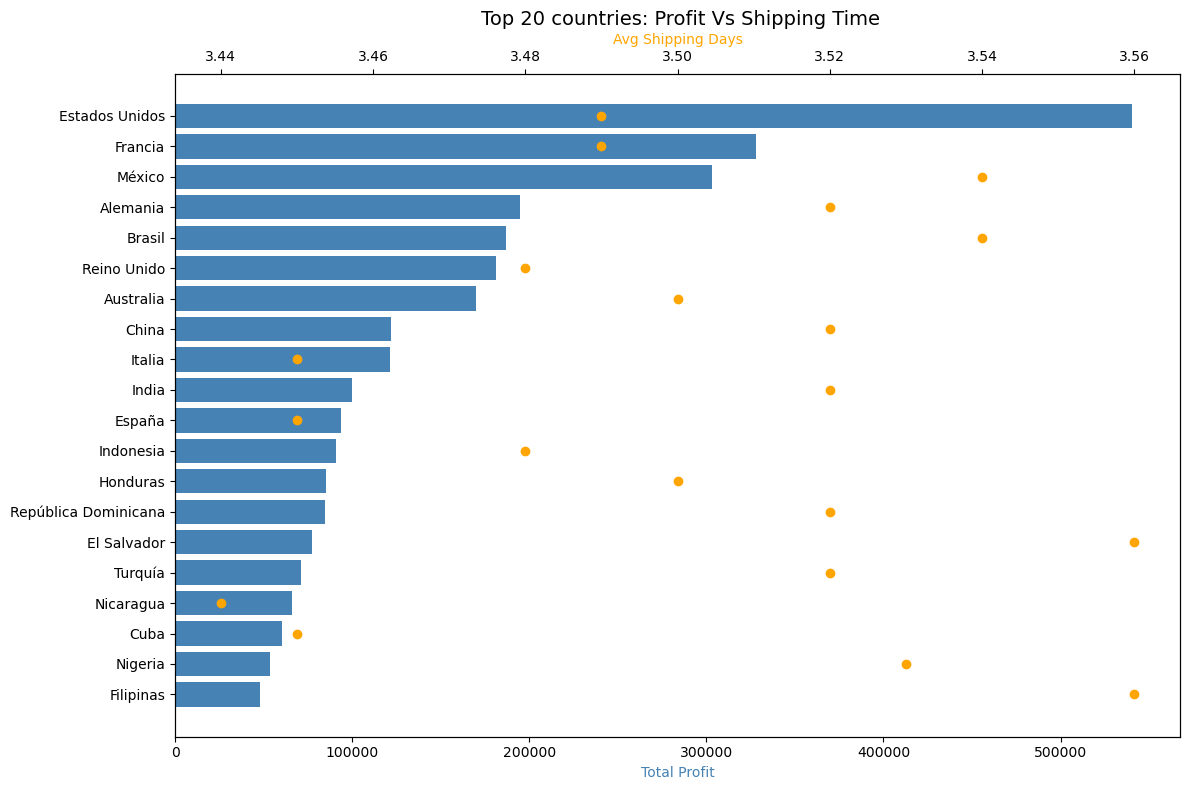

In [13]:
top20 = country_wise_shipping.nlargest(20, "total_profit").sort_values("total_profit")

fig, ax1 = plt.subplots(figsize=(12,8))
ax1.barh(top20["order_country"], top20["total_profit"], color="steelblue")
ax1.set_xlabel("Total Profit", color="steelblue")
ax1.set_title(" Top 20 countries: Profit Vs Shipping Time", fontsize=14)

ax2 = ax1.twiny()
ax2.plot(top20["avg_real_shipping_days"], top20["order_country"], "o", color="orange")
ax2.set_xlabel("Avg Shipping Days", color="orange")

plt.tight_layout()
plt.show()

In [14]:
country_wise_shipping[["avg_real_shipping_days", "total_profit"]].corr()

,avg_real_shipping_days,total_profit
avg_real_shipping_days,1.00000,-0.01945
total_profit,-0.01945,1.00000


## Key Finding
- Shipping speed isn't a meaningful driver of country profitability. Countries aren't more profitable because they ship faster, and slower shipping isn't quietly costing you profit at the country level. Whatever's driving profit differences between countries (order volume, product mix, pricing, market size) is a separate story from logistics speed.

## Q3 Which operational factors (shipping mode, market, category, customer segment) are actually driving late deliveries?

In [15]:
df["shipping_mode"].value_counts(ascending=True)

shipping_mode
Same Day            9737
First Class        27814
Second Class       35216
Standard Class    107752
Name: count, dtype: int64

In [16]:
late_by_mode = df.groupby("shipping_mode").agg(
    total_orders = ("order_id", "count"),
    late_orders = ("late_delivery_risk", "sum"),
    avg_real_shipping_days = ("days_for_shipping_(real)", "mean"),
    avg_scheduled_shipping_days = ("days_for_shipment_(scheduled)", "mean")
)

late_by_mode["late_rate_impact"] = ((late_by_mode["late_orders"]/late_by_mode["total_orders"])*100).round(2)
late_by_mode["shipping_gap"] = (late_by_mode["avg_real_shipping_days"] - late_by_mode["avg_scheduled_shipping_days"]).round(2)
late_by_mode.sort_values("late_rate_impact", ascending = False)

late_by_market = df.groupby("market").agg(
    total_orders = ("order_id", "count"),
    late_orders = ("late_delivery_risk", "sum")
)
late_by_market["late_rate_impact"] = ((late_by_market["late_orders"]/late_by_market["total_orders"])*100).round(2)
late_by_market.sort_values("late_rate_impact", ascending=False)    

,total_orders,late_orders,late_rate_impact
market,,,
Europe,50252,27743,55.21
Pacific Asia,41260,22712,55.05
USCA,25799,14138,54.80
Africa,11614,6340,54.59
LATAM,51594,28044,54.36


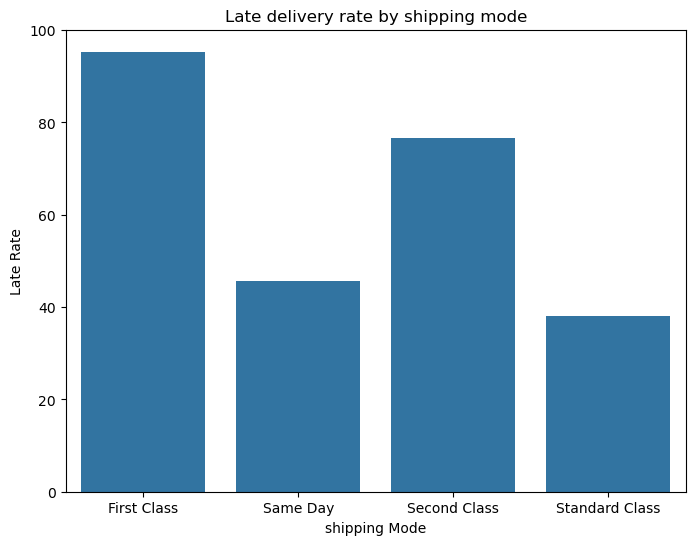

In [17]:
plt.figure(figsize=(8,6))
sns.barplot(
    data= late_by_mode.reset_index(),
    x="shipping_mode",
    y="late_rate_impact"
)
plt.title('Late delivery rate by shipping mode')
plt.ylabel('Late Rate')
plt.xlabel('shipping Mode')
plt.show()

In [18]:
late_by_mode

,total_orders,late_orders,avg_real_shipping_days,avg_scheduled_shipping_days,late_rate_impact,shipping_gap
shipping_mode,,,,,,
First Class,27814,26513,2.000000,1.0,95.32,1.00
Same Day,9737,4454,0.478279,0.0,45.74,0.48
Second Class,35216,26987,3.990828,2.0,76.63,1.99
Standard Class,107752,41023,3.995907,4.0,38.07,-0.00


### Key Insights
- Nearly 54–55% of orders are delivered late in every market.
- LATAM has the highest number of orders but the lowest delay percentage, indicating relatively better delivery performance despite handling the largest workload.
- Europe has the highest delay rate (55.21%), suggesting greater logistics inefficiencies.
- The difference between markets is less than 1%, indicating that late deliveries are a global operational issue rather than a problem isolated to one market.
- First Class is still faster overall, but it misses its promised delivery time more often.

## Q4
### A) Which category/product type takes the longest and delays the most, across all markets?

In [19]:
df.columns.tolist()

['payement_type',
 'days_for_shipping_(real)',
 'days_for_shipment_(scheduled)',
 'benefit_per_order',
 'sales_per_customer',
 'delivery_status',
 'late_delivery_risk',
 'category_id',
 'category_name',
 'customer_city',
 'customer_country',
 'customer_email',
 'customer_fname',
 'customer_id',
 'customer_lname',
 'customer_password',
 'customer_segment',
 'customer_state',
 'customer_street',
 'customer_zipcode',
 'department_id',
 'department_name',
 'latitude',
 'longitude',
 'market',
 'order_city',
 'order_country',
 'order_customer_id',
 'order_date_(dateorders)',
 'order_id',
 'order_item_cardprod_id',
 'order_item_discount',
 'order_item_discount_rate',
 'order_item_id',
 'order_item_product_price',
 'order_item_profit_ratio',
 'order_item_quantity',
 'sales',
 'order_item_total',
 'order_profit_per_order',
 'order_region',
 'order_state',
 'order_status',
 'product_card_id',
 'product_category_id',
 'product_description',
 'product_image',
 'product_name',
 'product_price',
 '

In [20]:
category_delay = df.groupby("category_name").agg(
    total_orders = ("order_id", "count"),
    late_orders = ("late_delivery_risk", "sum"),
    avg_real_shipping_days = ("days_for_shipping_(real)", "mean"),
    avg_scheduled_shipping_days = ("days_for_shipment_(scheduled)", "mean")
).round(2)

category_delay["late_rate_impact"] = ((category_delay["late_orders"]/category_delay["total_orders"])*100).round(2)
category_delay["shipping_gap"] = (category_delay["avg_real_shipping_days"] - category_delay["avg_scheduled_shipping_days"]).round(2)
category_delay.sort_values("late_rate_impact", ascending = False).reset_index()

,category_name,total_orders,late_orders,avg_real_shipping_days,avg_scheduled_shipping_days,late_rate_impact,shipping_gap
0,Golf Bags & Carts,61,42,3.34,2.57,68.85,0.77
1,Lacrosse,343,206,3.62,2.96,60.06,0.66
2,Pet Supplies,492,290,3.39,2.68,58.94,0.71
3,Cameras,592,344,3.34,2.69,58.11,0.65
4,Strength Training,111,64,3.75,3.08,57.66,0.67
5,As Seen on TV!,68,39,3.63,2.97,57.35,0.66
6,Music,434,248,3.48,2.91,57.14,0.57
7,Accessories,1780,1014,3.50,2.91,56.97,0.59
8,Fitness Accessories,309,176,3.57,2.96,56.96,0.61
9,Books,405,229,3.39,2.86,56.54,0.53


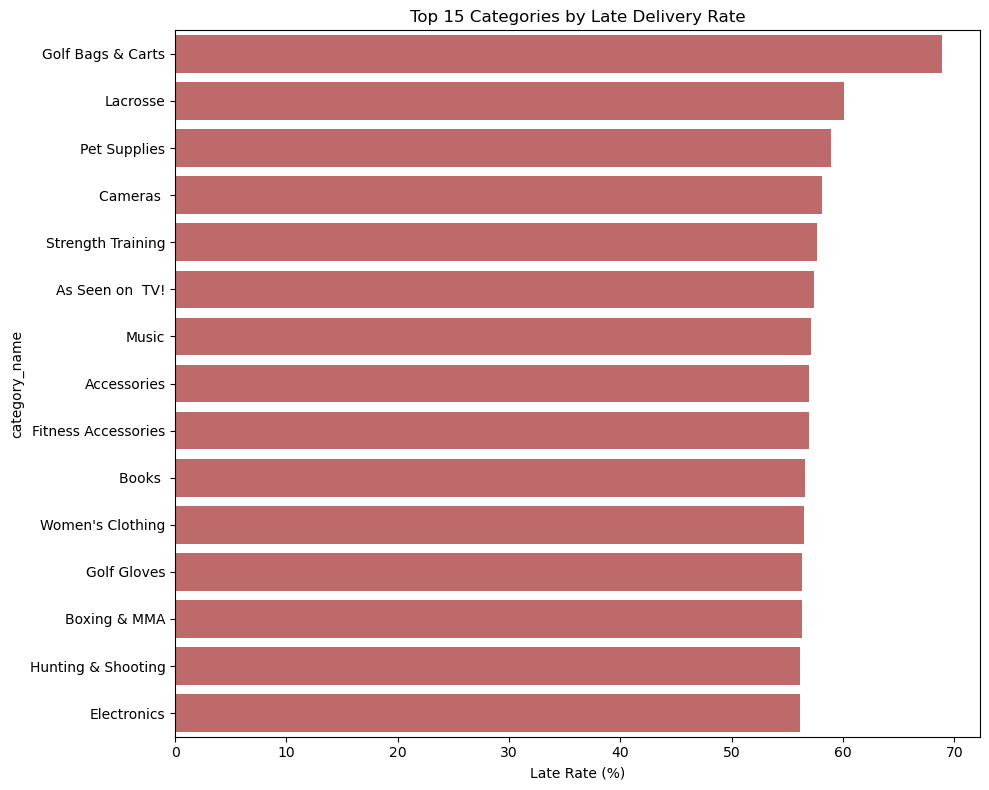

In [21]:
plt.figure(figsize=(10,8))
top_late_categories = category_delay.sort_values("late_rate_impact", ascending=False).head(15)
sns.barplot(data=top_late_categories.reset_index(), y="category_name", x="late_rate_impact", color="indianred")
plt.title("Top 15 Categories by Late Delivery Rate")
plt.xlabel("Late Rate (%)")
plt.tight_layout()
plt.show()

### B) Which market is dominated by which product/category?

In [22]:
market_category_sales = df.groupby(["market", "category_name"])["sales"].sum().reset_index()

top_category_per_market = market_category_sales.loc[
    market_category_sales.groupby("market")["sales"].idxmax()
    ].sort_values("sales", ascending=False)
top_category_per_market["sales"] = top_category_per_market["sales"].apply(format_currency)
top_category_per_market.reset_index(drop=True)

,market,category_name,sales
0,LATAM,Fishing,$2.03M
1,Europe,Fishing,$1.93M
2,Pacific Asia,Fishing,$1.47M
3,USCA,Fishing,$1.03M
4,Africa,Fishing,$473.98K


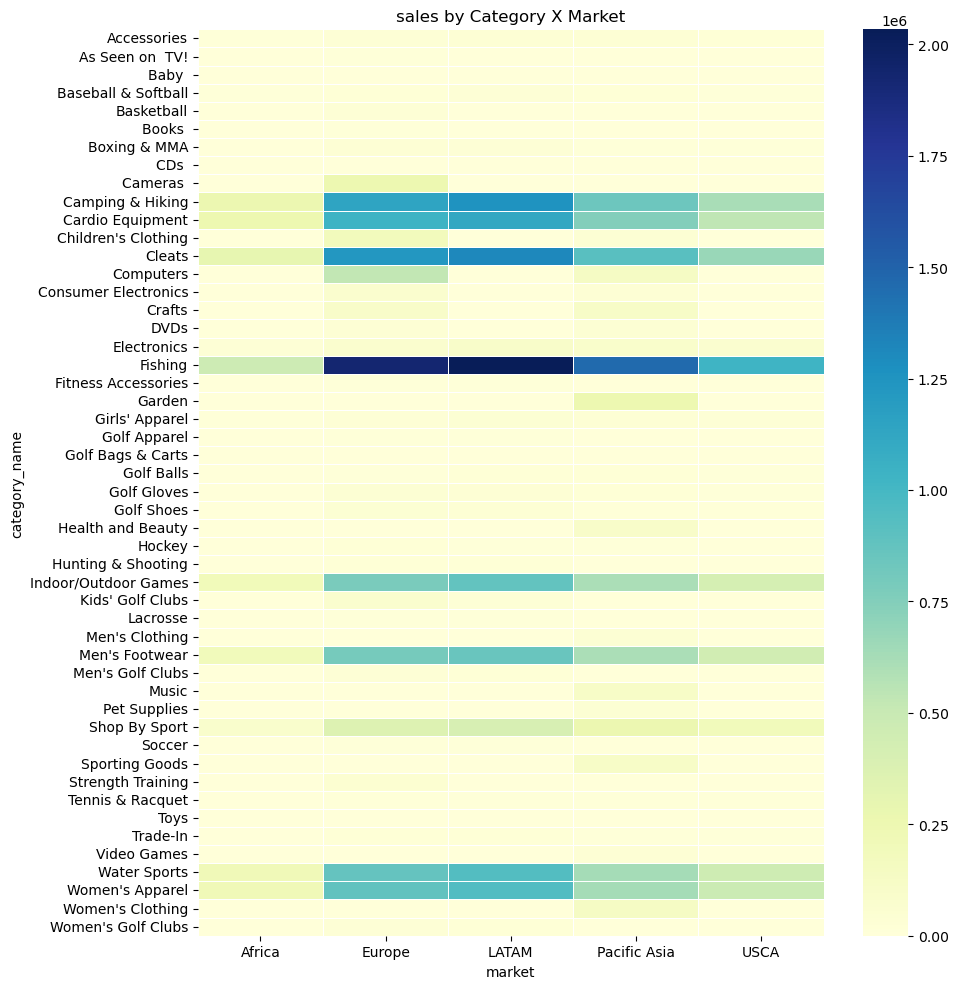

In [23]:
pivot = market_category_sales.pivot(index="category_name", columns="market", values="sales").fillna(0)
plt.figure(figsize=(10,10))
sns.heatmap(pivot,cmap="YlGnBu", linewidth=0.5)
plt.title("sales by Category X Market")
plt.tight_layout()
plt.show()

### C) Which product gives the maximum profit for each market?

In [24]:
market_product_profit = df.groupby(["market", "product_name"])["order_profit_per_order"].sum().reset_index()

top_product_per_market = market_product_profit.loc[
    market_product_profit.groupby("market")["order_profit_per_order"].idxmax()
].sort_values("order_profit_per_order", ascending=False)

top_product_per_market["order_profit_per_order"] = top_product_per_market["order_profit_per_order"].apply(format_currency)
top_product_per_market.reset_index(drop=True)

,market,product_name,order_profit_per_order
0,LATAM,Field & Stream Sportsman 16 Gun Fire Safe,$223.27K
1,Europe,Field & Stream Sportsman 16 Gun Fire Safe,$207.66K
2,Pacific Asia,Field & Stream Sportsman 16 Gun Fire Safe,$148.67K
3,USCA,Field & Stream Sportsman 16 Gun Fire Safe,$128.39K
4,Africa,Field & Stream Sportsman 16 Gun Fire Safe,$48.23K


In [25]:
df["product_name"].value_counts().sort_values().reset_index()

,product_name,count
0,SOLE E25 Elliptical,10
1,Bowflex SelectTech 1090 Dumbbells,10
2,Bushnell Pro X7 Jolt Slope Rangefinder,11
3,SOLE E35 Elliptical,15
4,Stiga Master Series ST3100 Competition Indoor,27
...,...,...
113,Field & Stream Sportsman 16 Gun Fire Safe,17325
114,O'Brien Men's Neoprene Life Vest,19298
115,Nike Men's Dri-FIT Victory Golf Polo,21035
116,Nike Men's CJ Elite 2 TD Football Cleat,22246


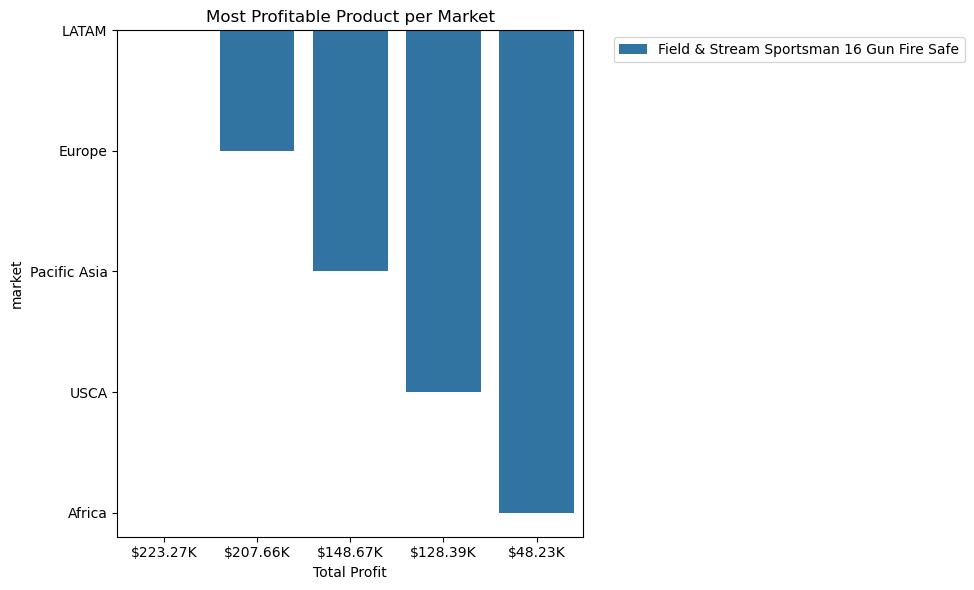

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_product_per_market, x="order_profit_per_order", y="market", hue="product_name", dodge=False)
plt.title("Most Profitable Product per Market")
plt.xlabel("Total Profit")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

In [27]:
df["order_status"].value_counts()

order_status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

In [28]:
from scipy import stats
print(df["delivery_status"].value_counts())
print()
print(df["order_status"].value_counts())

delivery_status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

order_status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64


In [29]:
late_profit = df[df["late_delivery_risk"] == 1]["order_profit_per_order"]
ontime_profit = df[df["late_delivery_risk"] == 0]["order_profit_per_order"]

print("late orders - mean profit: $", late_profit.mean().round(2), "| count:", len(late_profit))
print("ontime_profit - mean profit: $",ontime_profit.mean().round(2), "| count:", len(ontime_profit))

t_stat, p_val = stats.ttest_ind(late_profit, ontime_profit, equal_var=False)
print(f"\nt-stat: {t_stat:.3f}, p-value: {p_val:.6f}")

total_late_profit = late_profit.sum()
total_ontime_profit = ontime_profit.sum()
print(f"Total profit from late orders: $ {total_late_profit:,.2f}")
print(f"Total profit from ontime orders: $ {total_ontime_profit:,.2f}")

late orders - mean profit: $ 21.62 | count: 98977
ontime_profit - mean profit: $ 22.4 | count: 81542

t-stat: -1.587, p-value: 0.112539
Total profit from late orders: $ 2,140,051.68
Total profit from ontime orders: $ 1,826,851.29


### Stats Conclusion
- On-time deliveries earn slightly higher profit per order.
- However, the difference is not statistically significant (p = 0.1125).
- Late deliveries contribute more total profit only because they represent a larger share of all orders.
- This suggests that delivery delays do not have a measurable impact on per-order profitability in the current dataset, though they may still negatively affect customer satisfaction, retention, or brand reputation—factors not captured by these profit metrics.

In [30]:
df.columns.tolist()

['payement_type',
 'days_for_shipping_(real)',
 'days_for_shipment_(scheduled)',
 'benefit_per_order',
 'sales_per_customer',
 'delivery_status',
 'late_delivery_risk',
 'category_id',
 'category_name',
 'customer_city',
 'customer_country',
 'customer_email',
 'customer_fname',
 'customer_id',
 'customer_lname',
 'customer_password',
 'customer_segment',
 'customer_state',
 'customer_street',
 'customer_zipcode',
 'department_id',
 'department_name',
 'latitude',
 'longitude',
 'market',
 'order_city',
 'order_country',
 'order_customer_id',
 'order_date_(dateorders)',
 'order_id',
 'order_item_cardprod_id',
 'order_item_discount',
 'order_item_discount_rate',
 'order_item_id',
 'order_item_product_price',
 'order_item_profit_ratio',
 'order_item_quantity',
 'sales',
 'order_item_total',
 'order_profit_per_order',
 'order_region',
 'order_state',
 'order_status',
 'product_card_id',
 'product_category_id',
 'product_description',
 'product_image',
 'product_name',
 'product_price',
 '

In [31]:
df[["order_date_(dateorders)", "customer_id", "sales_per_customer"]].sort_values(by= "order_date_(dateorders)", ascending=True).reset_index()

,index,order_date_(dateorders),customer_id,sales_per_customer
0,33833,2015-01-01 00:00:00,11599,239.979996
1,77011,2015-01-01 00:21:00,256,193.990005
2,109322,2015-01-01 00:21:00,256,227.500000
3,87884,2015-01-01 00:21:00,256,107.889999
4,114915,2015-01-01 01:03:00,8827,159.940002
...,...,...,...,...
180514,160537,2018-01-31 22:14:00,20753,161.869995
180515,93905,2018-01-31 22:35:00,20754,172.660004
180516,0,2018-01-31 22:56:00,20755,314.640015
180517,52147,2018-01-31 23:17:00,20756,10.910000


In [32]:
customer_orders = (
    df.groupby(["customer_id"]).agg(
        total_orders=("order_id", "count"),
        profit_from_customer=("benefit_per_order", "sum"),
        avg_real_shipping_days = ("days_for_shipping_(real)", "mean"),
        avg_scheduled_shipping_days = ("days_for_shipment_(scheduled)", "mean")
    ).reset_index())

customer_orders = customer_orders[customer_orders["total_orders"]>1]
## customer_orders["profit_from_customer"] = customer_orders["profit_from_customer"].apply(format_currency)
customer_orders.head(20).round(2)

,customer_id,total_orders,profit_from_customer,avg_real_shipping_days,avg_scheduled_shipping_days
1,2,10,208.74,4.50,4.00
2,3,18,334.49,2.06,2.22
3,4,14,-439.98,2.57,2.00
4,5,7,309.85,3.14,2.57
5,6,15,893.65,4.40,3.20
6,7,22,964.89,4.09,4.00
7,8,19,529.93,3.26,3.53
8,9,14,-383.88,3.64,1.50
9,10,8,-151.22,4.50,4.00
10,11,12,294.92,3.17,3.67


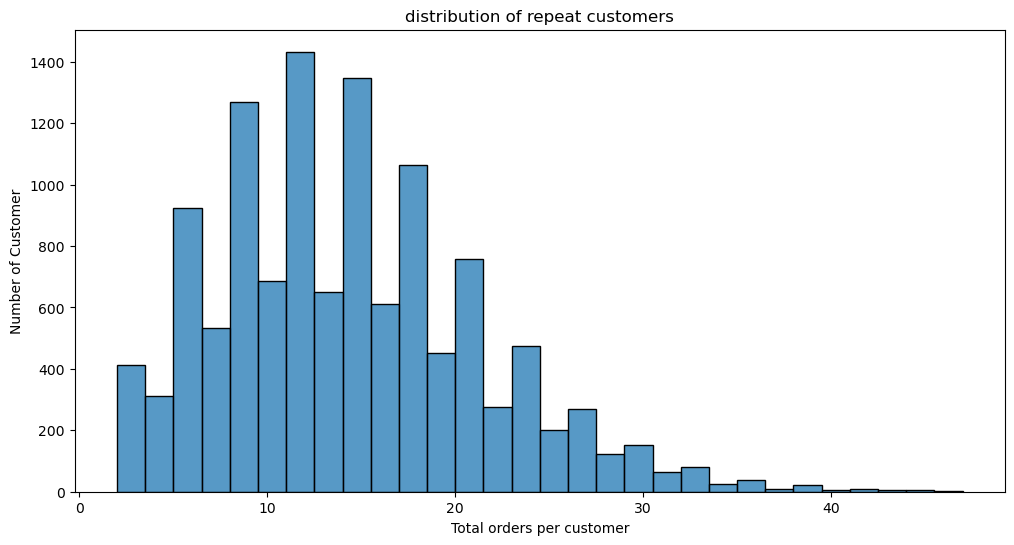

In [33]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=customer_orders,
    x="total_orders",
    bins=30
)
plt.title("distribution of repeat customers")
plt.xlabel("Total orders per customer")
plt.ylabel("Number of Customer")
plt.show()

### Customer loyalty
- tells us if delays are really affecting cutomer reorder rate

In [34]:
customer_loyalty = (
    df.groupby("customer_id")
      .agg(
          total_orders=("order_id", "count"),
          late_orders=("late_delivery_risk", "sum")
      )
      .reset_index()
)

customer_loyalty["late_rate"] = (
    customer_loyalty["late_orders"] /
    customer_loyalty["total_orders"] * 100
).round(2)
customer_loyalty

,customer_id,total_orders,late_orders,late_rate
0,1,1,1,100.00
1,2,10,3,30.00
2,3,18,0,0.00
3,4,14,11,78.57
4,5,7,5,71.43
...,...,...,...,...
20647,20753,1,1,100.00
20648,20754,1,0,0.00
20649,20755,1,0,0.00
20650,20756,1,0,0.00


<Axes: xlabel='late_rate', ylabel='total_orders'>

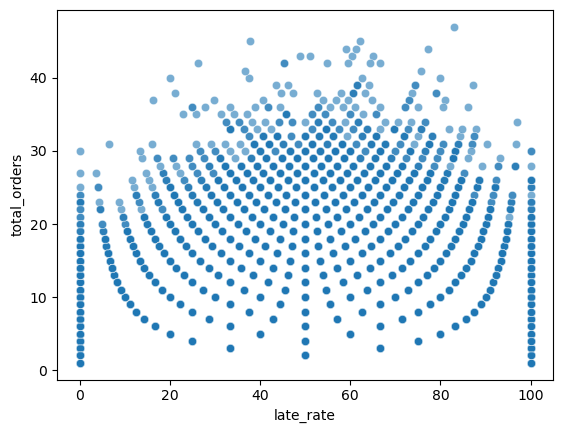

In [35]:
sns.scatterplot(
    data=customer_loyalty,
    x="late_rate",
    y="total_orders",
    alpha=0.6
)

In [36]:
customer_loyalty[["late_rate", "total_orders"]].corr()

,late_rate,total_orders
late_rate,1.000000,-0.001109
total_orders,-0.001109,1.000000


### Verdict-
- there is no significant correlation with the delays and customer loyalty 

In [37]:
df.groupby("market")["days_for_shipment_(scheduled)"].apply(lambda x: sorted(x.unique()))

market
Africa          [0, 1, 2, 4]
Europe          [0, 1, 2, 4]
LATAM           [0, 1, 2, 4]
Pacific Asia    [0, 1, 2, 4]
USCA            [0, 1, 2, 4]
Name: days_for_shipment_(scheduled), dtype: object

In [38]:
df["ship_gap"] = ((df["days_for_shipping_(real)"]- df["days_for_shipment_(scheduled)"]).round(2))

    
df.groupby("market").agg(
    avg_scheduled=("days_for_shipment_(scheduled)", "mean"),
    avg_real=("days_for_shipping_(real)", "mean"),
    gap=("ship_gap", "mean")
).sort_values("gap", ascending=False).round(2)

,avg_scheduled,avg_real,gap
market,,,
Europe,2.92,3.49,0.57
Pacific Asia,2.93,3.50,0.57
USCA,2.92,3.48,0.57
Africa,2.95,3.51,0.56
LATAM,2.95,3.51,0.56


In [39]:
df.groupby("shipping_mode").agg(
    avg_scheduled=("days_for_shipment_(scheduled)", "mean"),
    avg_real=("days_for_shipping_(real)", "mean"),
    gap=("ship_gap", "mean")
).sort_values("gap", ascending=False).round(2)

,avg_scheduled,avg_real,gap
shipping_mode,,,
Second Class,2.0,3.99,1.99
First Class,1.0,2.00,1.00
Same Day,0.0,0.48,0.48
Standard Class,4.0,4.00,-0.00


- **2** out of **4** modes are taking almost **double** the time in shipping
- the 2 premium class __(first and second)__  are over promising the delivery time
- Telling customer that order will arive early by choosing premium class is giving false hope and can hamper customer satisfaction
- We need to properly define the scheduled days 

In [41]:
df.to_sql("supply_chain", con = engine, if_exists="replace", index=False)
print("data uploaded")

data uploaded


In [42]:
df.columns

Index(['payement_type', 'days_for_shipping_(real)',
       'days_for_shipment_(scheduled)', 'benefit_per_order',
       'sales_per_customer', 'delivery_status', 'late_delivery_risk',
       'category_id', 'category_name', 'customer_city', 'customer_country',
       'customer_email', 'customer_fname', 'customer_id', 'customer_lname',
       'customer_password', 'customer_segment', 'customer_state',
       'customer_street', 'customer_zipcode', 'department_id',
       'department_name', 'latitude', 'longitude', 'market', 'order_city',
       'order_country', 'order_customer_id', 'order_date_(dateorders)',
       'order_id', 'order_item_cardprod_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_id', 'order_item_product_price',
       'order_item_profit_ratio', 'order_item_quantity', 'sales',
       'order_item_total', 'order_profit_per_order', 'order_region',
       'order_state', 'order_status', 'product_card_id', 'product_category_id',
       'product_descriptio

In [43]:
drop_cols = ["customer_email", "customer_lname", "customer_fname", "product_card_id", "product_category_id",
             "product_description","product_image", "product_status", "customer_zipcode", "customer_state",
             "customer_street", "customer_zipcode","customer_password","order_item_cardprod_id", "order_city", "order_customer_id", "department_id", "department_name","longitude", "latitude"
            ]
df = df.drop(columns=drop_cols)

In [44]:
df.columns

Index(['payement_type', 'days_for_shipping_(real)',
       'days_for_shipment_(scheduled)', 'benefit_per_order',
       'sales_per_customer', 'delivery_status', 'late_delivery_risk',
       'category_id', 'category_name', 'customer_city', 'customer_country',
       'customer_id', 'customer_segment', 'market', 'order_country',
       'order_date_(dateorders)', 'order_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_id', 'order_item_product_price',
       'order_item_profit_ratio', 'order_item_quantity', 'sales',
       'order_item_total', 'order_profit_per_order', 'order_region',
       'order_state', 'order_status', 'product_name', 'product_price',
       'shipping_date_(dateorders)', 'shipping_mode', 'ship_gap'],
      dtype='object')

In [45]:
df.to_csv("supply_chain_cleaned", index=False)

In [46]:
df.to_sql("supply_chain", con = engine, if_exists="replace", index=False)
print("data uploaded")

data uploaded


In [47]:
df.columns

Index(['payement_type', 'days_for_shipping_(real)',
       'days_for_shipment_(scheduled)', 'benefit_per_order',
       'sales_per_customer', 'delivery_status', 'late_delivery_risk',
       'category_id', 'category_name', 'customer_city', 'customer_country',
       'customer_id', 'customer_segment', 'market', 'order_country',
       'order_date_(dateorders)', 'order_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_id', 'order_item_product_price',
       'order_item_profit_ratio', 'order_item_quantity', 'sales',
       'order_item_total', 'order_profit_per_order', 'order_region',
       'order_state', 'order_status', 'product_name', 'product_price',
       'shipping_date_(dateorders)', 'shipping_mode', 'ship_gap'],
      dtype='object')